In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pysolar

(np.float64(-0.5), np.float64(848.5), np.float64(565.5), np.float64(-0.5))

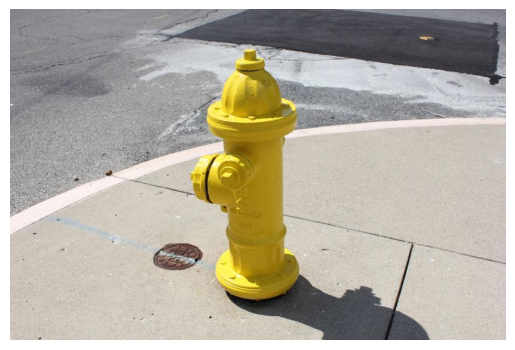

In [2]:
# Load image
img = cv2.imread('./test2.jpg')

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [3]:
# Shadow Detection using Color Space Analysis
def detect_shadows(image):
    """
    Detect shadows in the image using multiple color space analysis
    """
    # Convert to different color spaces for shadow detection
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    
    # Method 1: HSV-based shadow detection
    # Shadows typically have low value (V) and saturation (S)
    lower_shadow_hsv = np.array([0, 0, 0])
    upper_shadow_hsv = np.array([180, 255, 100])  # Adjust the V value for shadow threshold
    shadow_mask_hsv = cv2.inRange(hsv, lower_shadow_hsv, upper_shadow_hsv)
    
    # Method 2: LAB-based shadow detection
    # Shadows have higher 'a' values and lower 'L' values
    l_channel = lab[:, :, 0]
    a_channel = lab[:, :, 1]
    
    # Create shadow mask based on L channel (brightness)
    shadow_mask_lab = cv2.threshold(l_channel, 80, 255, cv2.THRESH_BINARY_INV)[1]
    
    
    # Combine different shadow detection methods
    combined_shadow_mask = cv2.bitwise_or(shadow_mask_hsv, shadow_mask_lab)
    
    # Apply morphological operations to clean up the shadow mask
    kernel = np.ones((5, 5), np.uint8)
    combined_shadow_mask = cv2.morphologyEx(combined_shadow_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    combined_shadow_mask = cv2.morphologyEx(combined_shadow_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find shadow contours
    shadow_contours, _ = cv2.findContours(combined_shadow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter shadow contours by area
    min_shadow_area = 300
    filtered_shadow_contours = [cnt for cnt in shadow_contours if cv2.contourArea(cnt) > min_shadow_area]
    
    return filtered_shadow_contours, combined_shadow_mask, shadow_mask_hsv, shadow_mask_lab

In [4]:
filtered_shadow_contours, combined_shadow_mask, shadow_mask_hsv, shadow_mask_lab = detect_shadows(img)

Shadows Detected 2


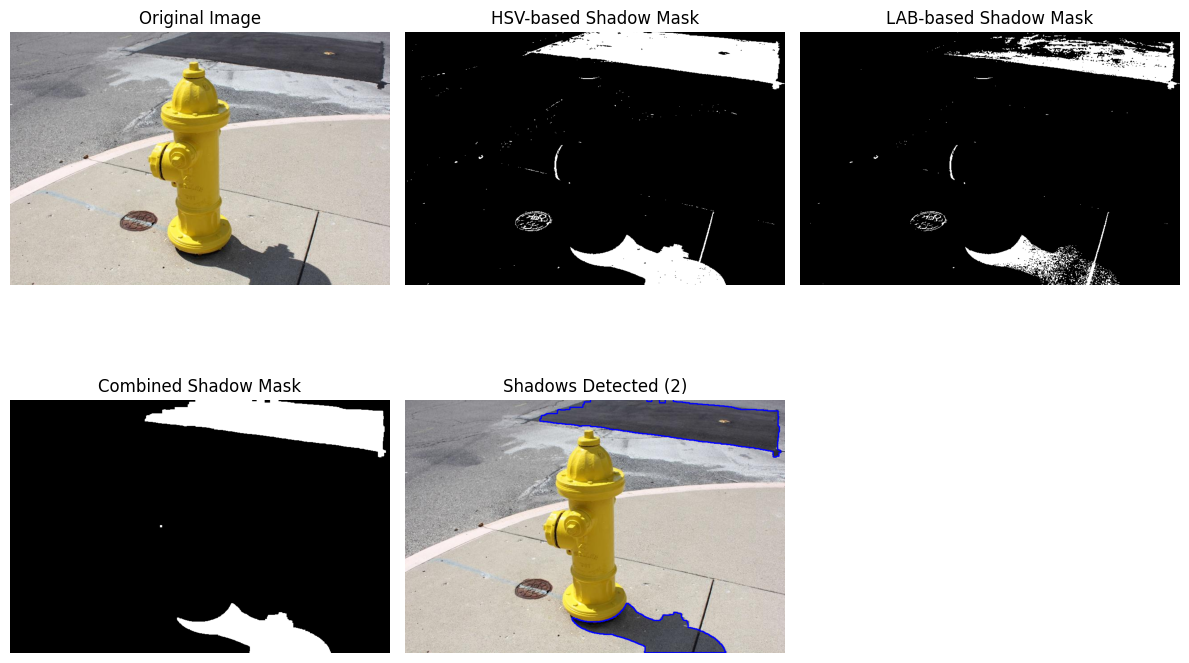

In [5]:
plt.figure(figsize=(12,8))

# Row 1
plt.subplot(2,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,2)
plt.title("HSV-based Shadow Mask")
plt.imshow(shadow_mask_hsv, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("LAB-based Shadow Mask")
plt.imshow(shadow_mask_lab, cmap='gray')
plt.axis('off')

# Row 2
plt.subplot(2,3,4)
plt.title("Combined Shadow Mask")
plt.imshow(combined_shadow_mask, cmap='gray')
plt.axis('off')

img_with_shadows = img.copy()
cv2.drawContours(img_with_shadows, filtered_shadow_contours, -1, (255, 0, 0), 2)
plt.subplot(2,3,5)
plt.title(f"Shadows Detected ({len(filtered_shadow_contours)})")
print("Shadows Detected",len(filtered_shadow_contours))
plt.imshow(cv2.cvtColor(img_with_shadows, cv2.COLOR_BGR2RGB))
plt.axis('off')


plt.tight_layout()
plt.show()

In [6]:
def find_individual_areas(binary_mask, min_area=0):
    """
    Find the area of each connected component in a binary image
    
    Parameters:
    binary_mask: binary image (0s and 255s or 0s and 1s)
    min_area: minimum area threshold to include component
    
    Returns:
    areas: list of areas for each component
    labeled_img: image with each component labeled differently
    num_components: number of components found
    component_info: detailed info about each component
    """
    # Find connected components
    num_labels, labeled_img, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    
    # Extract areas (skip background which is label 0)
    areas = []
    component_info = []
    
    for i in range(1, num_labels):  # Start from 1 to skip background
        area = stats[i, cv2.CC_STAT_AREA]
        
        # Filter by minimum area
        if area < min_area:
            continue
            
        left = stats[i, cv2.CC_STAT_LEFT]
        top = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        centroid = centroids[i]
        
        # Calculate maximum length (diagonal of bounding box)
        max_length_bbox = np.sqrt(width**2 + height**2)
        
        # Find contour for this component to get actual maximum length
        component_mask = (labeled_img == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        max_length_actual = 0
        box = None
        if len(contours) > 0:
            # Get the minimum area rectangle (rotated rectangle)
            rect = cv2.minAreaRect(contours[0])
            box = cv2.boxPoints(rect)
            box = np.intp(box)  # Changed from np.int0 to np.intp
            
            # Calculate the lengths of the rectangle sides
            side1 = np.linalg.norm(box[0] - box[1])
            side2 = np.linalg.norm(box[1] - box[2])
            max_length_actual = max(side1, side2)
        
        areas.append(area)
        component_info.append({
            'label': i,
            'area': area,
            'bbox': (left, top, width, height),
            'centroid': centroid,
            'max_length_bbox': max_length_bbox,
            'max_length_actual': max_length_actual,
            'rotated_rect': box
        })
    
    return areas, labeled_img, len(component_info), component_info

In [7]:
# Example usage with your shadow mask - only areas > 2000 pixels
shadow_areas, shadow_labeled_img, shadows_num_components, shadows_component_info = find_individual_areas(combined_shadow_mask, min_area=2000)

Number of shadow regions (area > 2000): 2
Individual areas: [np.int32(37465), np.int32(18046)]
Total shadow area: 55511 pixels

Detailed info for each component:
  Component 1:
    Area: 37465 pixels
    Max Length (BBox diagonal): 554.46 pixels
    Max Length (Actual): 543.07 pixels
    Centroid: [609.57312158  49.32174029]
  Component 3:
    Area: 18046 pixels
    Max Length (BBox diagonal): 361.47 pixels
    Max Length (Actual): 351.87 pixels
    Centroid: [559.12058074 520.52432672]


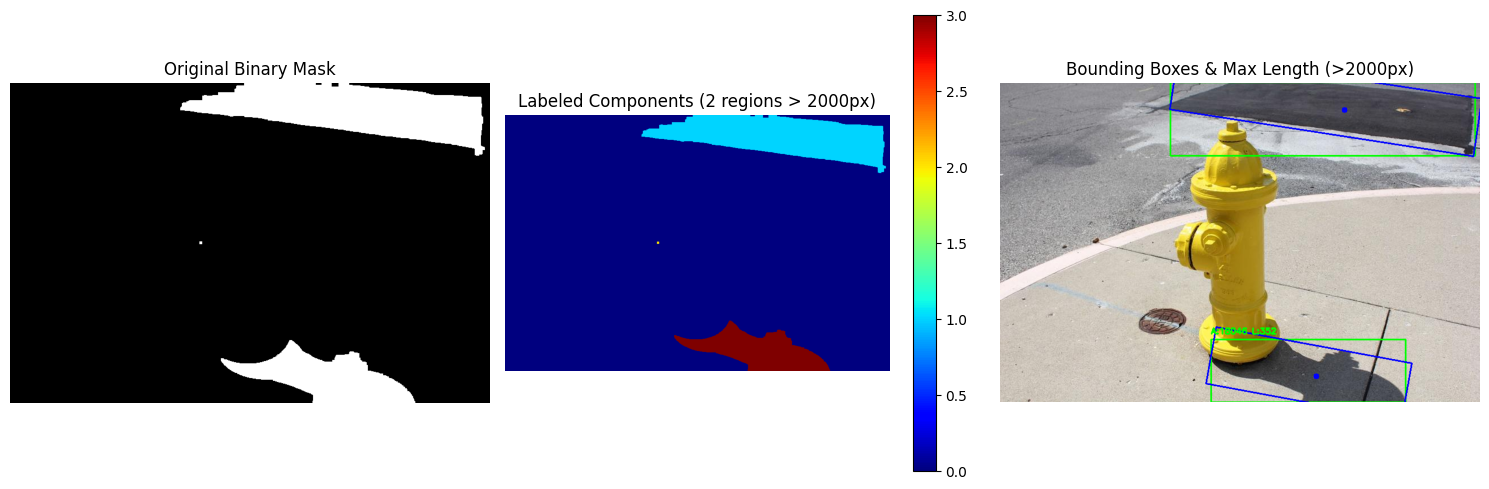

In [8]:
print(f"Number of shadow regions (area > 2000): {shadows_num_components}")
print(f"Individual areas: {shadow_areas}")
print(f"Total shadow area: {sum(shadow_areas)} pixels")
print(f"\nDetailed info for each component:")
for info in shadows_component_info:
    print(f"  Component {info['label']}:")
    print(f"    Area: {info['area']} pixels")
    print(f"    Max Length (BBox diagonal): {info['max_length_bbox']:.2f} pixels")
    print(f"    Max Length (Actual): {info['max_length_actual']:.2f} pixels")
    print(f"    Centroid: {info['centroid']}")

# Visualize labeled components
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Binary Mask")
plt.imshow(combined_shadow_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Labeled Components ({shadows_num_components} regions > 2000px)")
plt.imshow(shadow_labeled_img, cmap='jet')
plt.colorbar()
plt.axis('off')

# Draw bounding boxes and rotated rectangles on original image
img_with_boxes = img.copy()
for info in shadows_component_info:
    left, top, width, height = info['bbox']
    
    # Draw regular bounding box
    cv2.rectangle(img_with_boxes, (left, top), (left + width, top + height), (0, 255, 0), 2)
    
    # Draw rotated rectangle (minimum area rectangle)
    if info['rotated_rect'] is not None:
        cv2.drawContours(img_with_boxes, [info['rotated_rect']], 0, (255, 0, 0), 2)
    
    # Draw centroid
    cx, cy = int(info['centroid'][0]), int(info['centroid'][1])
    cv2.circle(img_with_boxes, (cx, cy), 5, (255, 0, 0), -1)
    
    # Add area and max length text
    text = f"A:{info['area']} L:{info['max_length_actual']:.0f}"
    cv2.putText(img_with_boxes, text, (left, top - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.subplot(1, 3, 3)
plt.title("Bounding Boxes & Max Length (>2000px)")
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
def kmeans_object_segmentation(image, n_clusters=2, object_cluster_index=None):
    """
    Segment objects from background using K-means clustering
    
    Parameters:
    image: input BGR image
    n_clusters: number of clusters (default=2: background and object)
    object_cluster_index: which cluster is the object (if None, auto-detect brightest)
    
    Returns:
    object_mask: binary mask of the object
    object_contours: contours of the object
    segmented_img: segmented image with cluster colors
    labels: cluster labels for each pixel
    centers: cluster centers (BGR colors)
    """
    # Reshape image to 2D array of pixels
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    
    # Define K-means criteria
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    
    # Apply K-means clustering
    _, labels, centers = cv2.kmeans(pixel_values, n_clusters, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    
    # Convert back to 8-bit values
    centers = np.uint8(centers)
    
    # Reshape labels to image shape
    labels = labels.reshape(image.shape[:2])
    
    # Auto-detect object cluster (brightest/most colorful cluster)
    if object_cluster_index is None:
        # Calculate brightness and saturation for each cluster
        cluster_scores = []
        for i in range(n_clusters):
            cluster_color = centers[i]
            # Convert to HSV to get saturation and value
            hsv_color = cv2.cvtColor(np.uint8([[cluster_color]]), cv2.COLOR_BGR2HSV)[0][0]
            saturation = hsv_color[1]
            value = hsv_color[2]
            # Score: higher saturation + higher brightness = likely object
            score = saturation * 0.6 + value * 0.4
            cluster_scores.append(score)
        
        # Select cluster with highest score
        object_cluster_index = np.argmax(cluster_scores)
    
    # Create object mask
    object_mask = np.where(labels == object_cluster_index, 255, 0).astype(np.uint8)
    
    # Clean up mask with morphological operations
    kernel = np.ones((5, 5), np.uint8)
    object_mask = cv2.morphologyEx(object_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    object_mask = cv2.morphologyEx(object_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    # Find contours
    contours, _ = cv2.findContours(object_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter by area
    min_area = 500
    filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    
    # Fill pixels with cluster colors to create segmented image
    segmented = centers[labels.flatten()]
    segmented = segmented.reshape(image.shape)
    
    return object_mask, filtered_contours, segmented, labels, centers

In [10]:
def visualize_kmeans_segmentation(image, object_mask, contours, segmented, labels, centers):
    """
    Visualize K-means segmentation results
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Original image
    axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Segmented image (clustered)
    axes[0, 1].imshow(cv2.cvtColor(segmented.astype(np.uint8), cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title(f'K-means Segmented ({len(centers)} clusters)')
    axes[0, 1].axis('off')
    
    # Cluster labels
    axes[0, 2].imshow(labels, cmap='jet')
    axes[0, 2].set_title('Cluster Labels')
    axes[0, 2].axis('off')
    
    # Object mask
    axes[1, 0].imshow(object_mask, cmap='gray')
    axes[1, 0].set_title('Object Mask')
    axes[1, 0].axis('off')
    
    # Object boundary
    img_with_boundary = image.copy()
    cv2.drawContours(img_with_boundary, contours, -1, (0, 255, 0), 3)
    axes[1, 1].imshow(cv2.cvtColor(img_with_boundary, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title(f'Object Boundary ({len(contours)} objects)')
    axes[1, 1].axis('off')
    
    # Object extracted (masked)
    masked_object = cv2.bitwise_and(image, image, mask=object_mask)
    axes[1, 2].imshow(cv2.cvtColor(masked_object, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('Extracted Object')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

Number of objects detected: 4
Number of clusters: 2


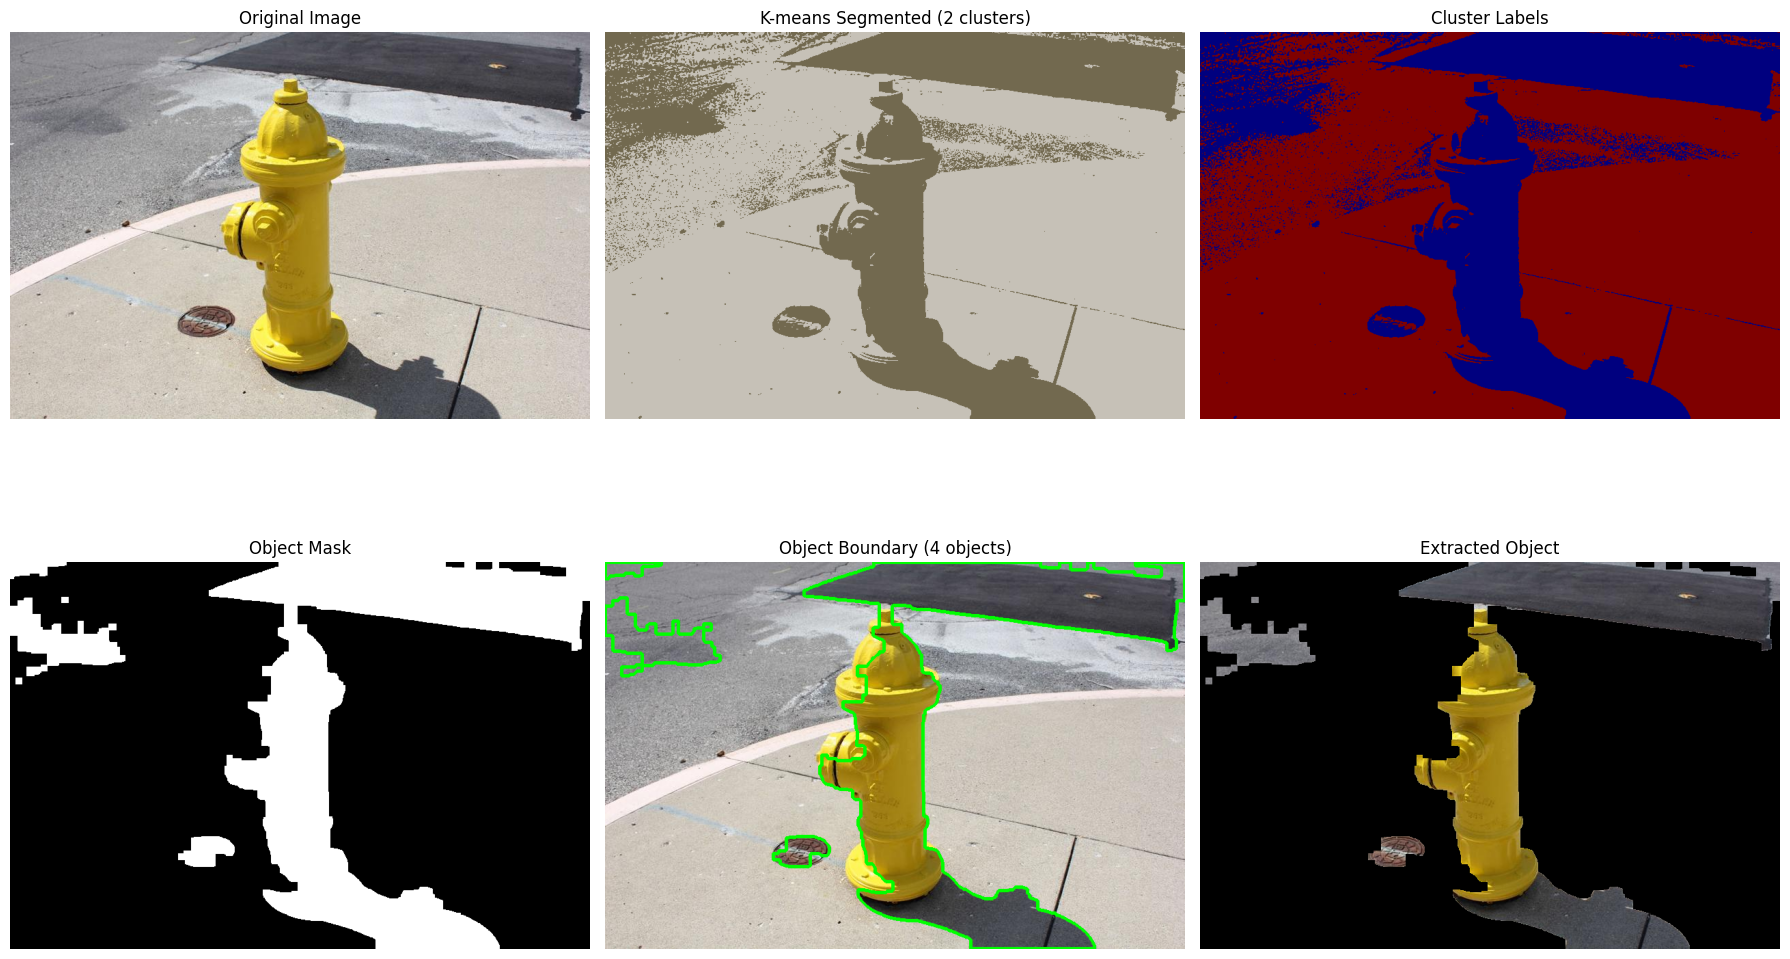

In [11]:
# Segment object using K-means with 2 clusters
object_mask, object_contours, segmented_img, labels, centers = kmeans_object_segmentation(img, n_clusters=2)

print(f"Number of objects detected: {len(object_contours)}")
print(f"Number of clusters: {len(centers)}")

# Visualize results
visualize_kmeans_segmentation(img, object_mask, object_contours, segmented_img, labels, centers)

Original objects detected: 4
Shadow regions detected: 2
Real objects (after shadow removal): 5


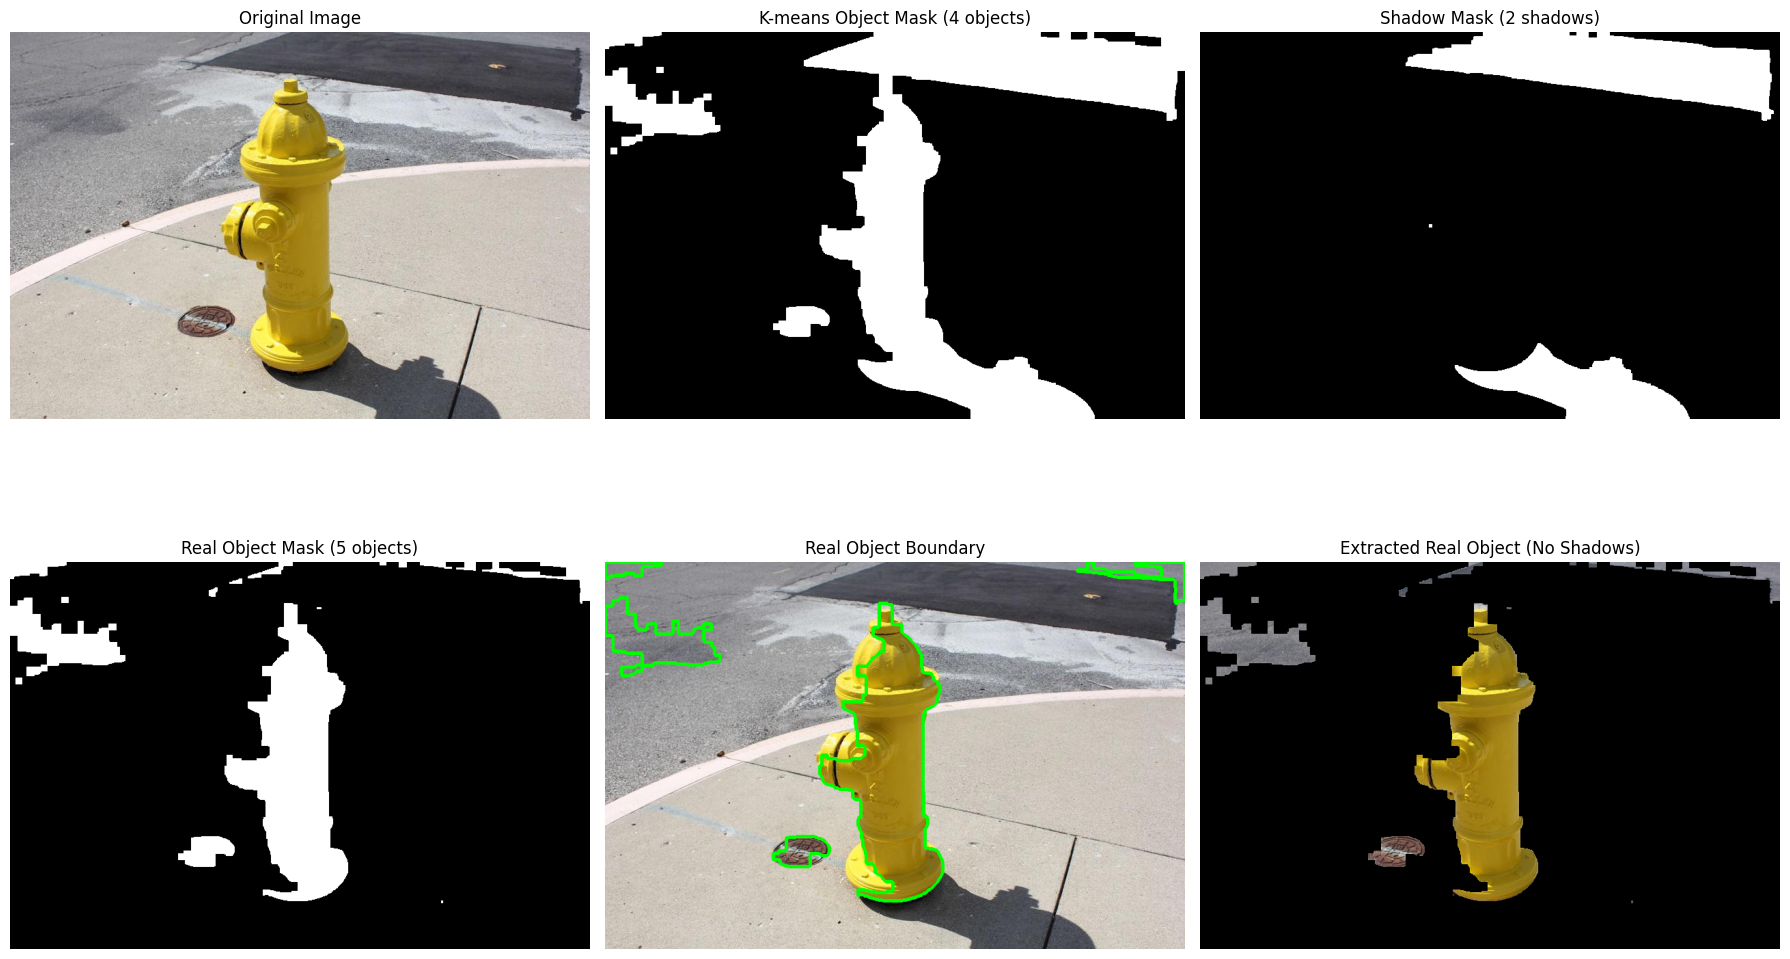

In [12]:
# Subtract shadows from the object mask to get the real object
real_object_mask = cv2.subtract(object_mask, combined_shadow_mask)

# Clean up the mask with morphological operations
kernel = np.ones((3, 3), np.uint8)
real_object_mask = cv2.morphologyEx(real_object_mask, cv2.MORPH_OPEN, kernel, iterations=1)
real_object_mask = cv2.morphologyEx(real_object_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

# Find contours of the real object
real_object_contours, _ = cv2.findContours(real_object_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter by area
min_area = 500
filtered_real_contours = [cnt for cnt in real_object_contours if cv2.contourArea(cnt) > min_area]

print(f"Original objects detected: {len(object_contours)}")
print(f"Shadow regions detected: {len(filtered_shadow_contours)}")
print(f"Real objects (after shadow removal): {len(filtered_real_contours)}")

# Visualize the comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# K-means object mask
axes[0, 1].imshow(object_mask, cmap='gray')
axes[0, 1].set_title(f'K-means Object Mask ({len(object_contours)} objects)')
axes[0, 1].axis('off')

# Shadow mask
axes[0, 2].imshow(combined_shadow_mask, cmap='gray')
axes[0, 2].set_title(f'Shadow Mask ({len(filtered_shadow_contours)} shadows)')
axes[0, 2].axis('off')

# Real object mask (after shadow subtraction)
axes[1, 0].imshow(real_object_mask, cmap='gray')
axes[1, 0].set_title(f'Real Object Mask ({len(filtered_real_contours)} objects)')
axes[1, 0].axis('off')

# Real object boundary on original image
img_with_real_boundary = img.copy()
cv2.drawContours(img_with_real_boundary, filtered_real_contours, -1, (0, 255, 0), 3)
axes[1, 1].imshow(cv2.cvtColor(img_with_real_boundary, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Real Object Boundary')
axes[1, 1].axis('off')

# Extracted real object (without shadows)
real_object_extracted = cv2.bitwise_and(img, img, mask=real_object_mask)
axes[1, 2].imshow(cv2.cvtColor(real_object_extracted, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Extracted Real Object (No Shadows)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Total regions found: 16
Individual areas before filtering: [np.int32(1287), np.int32(508), np.int32(50), np.int32(96), np.int32(283), np.int32(245), np.int32(2472), np.int32(106), np.int32(132), np.int32(99), np.int32(8894), np.int32(39749), np.int32(21), np.int32(100), np.int32(2529), np.int32(12)]
Total area before filtering: 56583 pixels

Regions with area >= 1000 pixels: 2
Filtered areas: [np.int32(8894), np.int32(39749)]
Total area after filtering: 48643 pixels

Number of filtered contours: 2


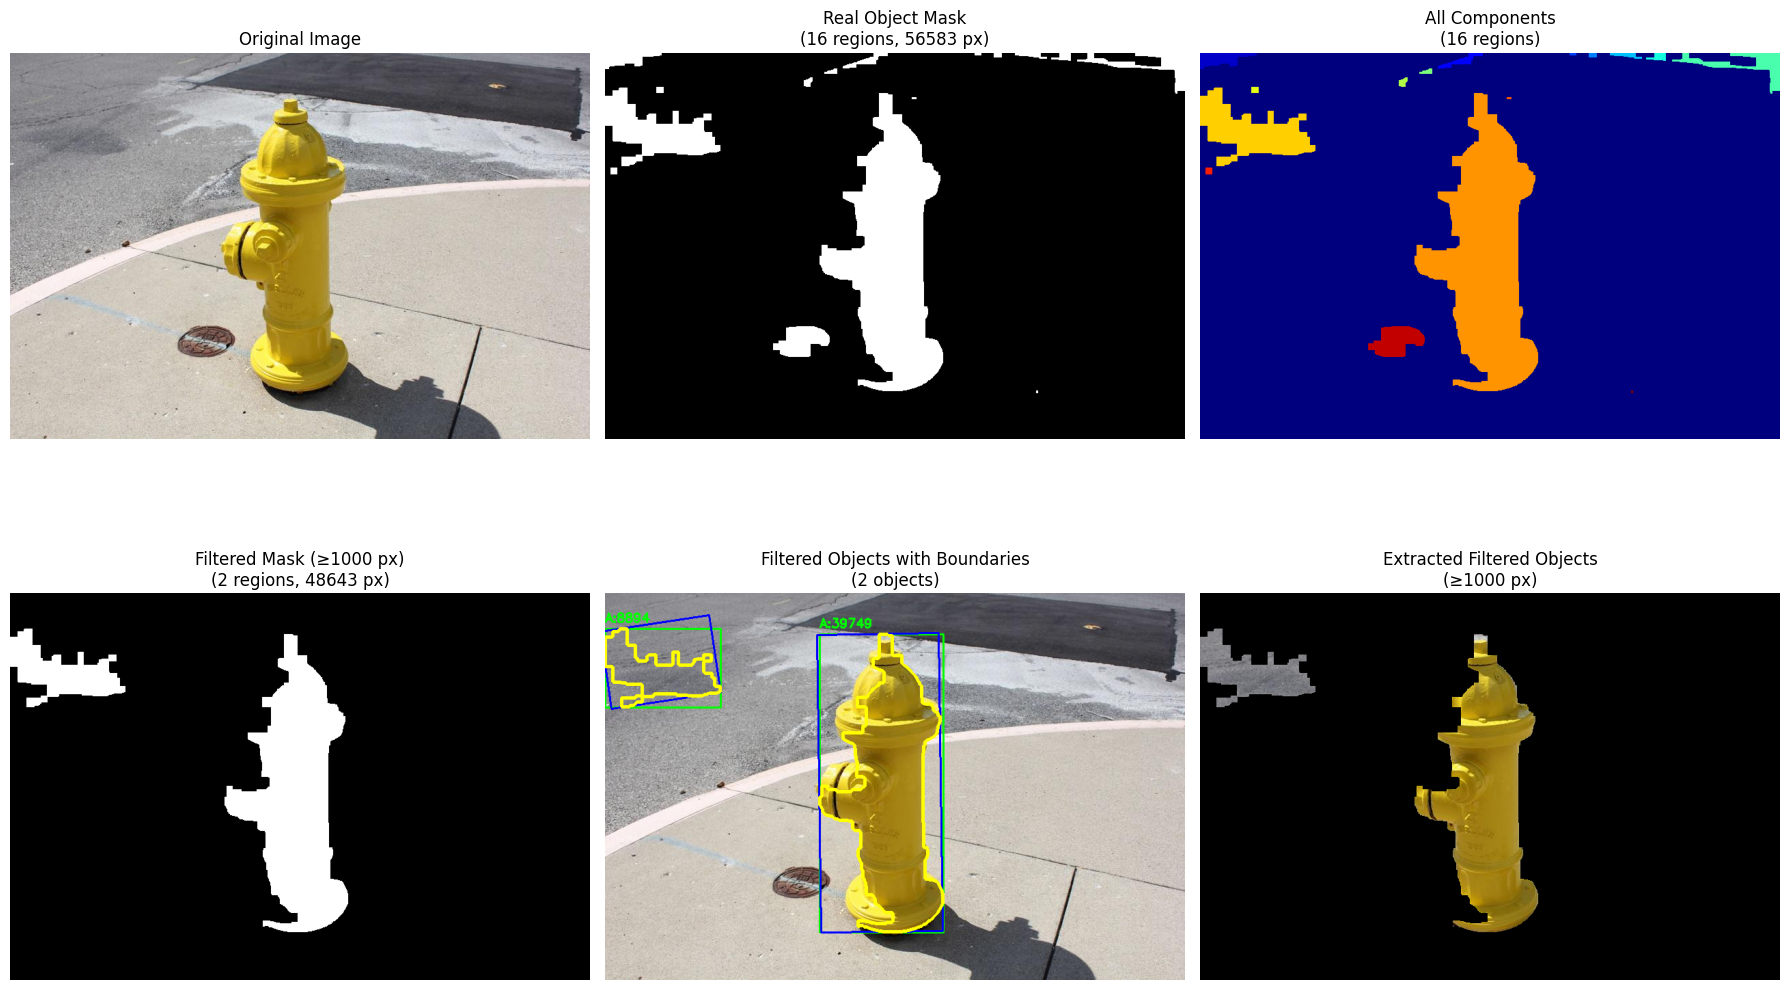


Detailed info for filtered components (area >= 1000):
  Component 11:
    Area: 8894 pixels
    Max Length (Actual): 160.80 pixels
    Centroid: (73.6, 115.3)
    BBox: (np.int32(0), np.int32(52), np.int32(169), np.int32(115))
  Component 12:
    Area: 39749 pixels
    Max Length (Actual): 436.04 pixels
    Centroid: (419.2, 296.7)
    BBox: (np.int32(314), np.int32(60), np.int32(181), np.int32(436))


In [13]:
# Calculate areas of each region in the real object mask and filter by area
real_areas, real_labeled_img, real_num_components, real_component_info = find_individual_areas(real_object_mask, min_area=0)

print(f"Total regions found: {real_num_components}")
print(f"Individual areas before filtering: {real_areas}")
print(f"Total area before filtering: {sum(real_areas)} pixels\n")

# Filter regions with area >= 1000 pixels
filtered_component_info = [info for info in real_component_info if info['area'] >= 3000]
filtered_areas = [info['area'] for info in filtered_component_info]

print(f"Regions with area >= 1000 pixels: {len(filtered_component_info)}")
print(f"Filtered areas: {filtered_areas}")
print(f"Total area after filtering: {sum(filtered_areas)} pixels\n")

# Create a new mask with only filtered regions (area >= 1000)
filtered_real_mask = np.zeros_like(real_object_mask)
for info in filtered_component_info:
    # Create mask for this component
    component_mask = (real_labeled_img == info['label']).astype(np.uint8) * 255
    filtered_real_mask = cv2.bitwise_or(filtered_real_mask, component_mask)

# Find contours of filtered objects
filtered_real_object_contours, _ = cv2.findContours(filtered_real_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Number of filtered contours: {len(filtered_real_object_contours)}")

# Visualize the filtering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Real object mask (before filtering)
axes[0, 1].imshow(real_object_mask, cmap='gray')
axes[0, 1].set_title(f'Real Object Mask\n({real_num_components} regions, {sum(real_areas)} px)')
axes[0, 1].axis('off')

# Labeled components (before filtering)
axes[0, 2].imshow(real_labeled_img, cmap='jet')
axes[0, 2].set_title(f'All Components\n({real_num_components} regions)')
axes[0, 2].axis('off')

# Filtered mask (area >= 1000)
axes[1, 0].imshow(filtered_real_mask, cmap='gray')
axes[1, 0].set_title(f'Filtered Mask (≥1000 px)\n({len(filtered_component_info)} regions, {sum(filtered_areas)} px)')
axes[1, 0].axis('off')

# Filtered objects with boundaries
img_with_filtered_boundary = img.copy()
for info in filtered_component_info:
    left, top, width, height = info['bbox']
    
    # Draw bounding box
    cv2.rectangle(img_with_filtered_boundary, (left, top), (left + width, top + height), (0, 255, 0), 2)
    
    # Draw rotated rectangle
    if info['rotated_rect'] is not None:
        cv2.drawContours(img_with_filtered_boundary, [info['rotated_rect']], 0, (255, 0, 0), 2)
    
    # Add area text
    text = f"A:{info['area']}"
    cv2.putText(img_with_filtered_boundary, text, (left, top - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

cv2.drawContours(img_with_filtered_boundary, filtered_real_object_contours, -1, (0, 255, 255), 3)
axes[1, 1].imshow(cv2.cvtColor(img_with_filtered_boundary, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Filtered Objects with Boundaries\n({len(filtered_component_info)} objects)')
axes[1, 1].axis('off')

# Extracted filtered objects
filtered_extracted = cv2.bitwise_and(img, img, mask=filtered_real_mask)
axes[1, 2].imshow(cv2.cvtColor(filtered_extracted, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title(f'Extracted Filtered Objects\n(≥1000 px)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Print detailed info for filtered components
print("\nDetailed info for filtered components (area >= 1000):")
for info in filtered_component_info:
    print(f"  Component {info['label']}:")
    print(f"    Area: {info['area']} pixels")
    print(f"    Max Length (Actual): {info['max_length_actual']:.2f} pixels")
    print(f"    Centroid: ({info['centroid'][0]:.1f}, {info['centroid'][1]:.1f})")
    print(f"    BBox: {info['bbox']}")

Number of detected objects: 2
Number of filtered shadows (area > 2000 px): 2
Using shadows from previous cell: 2 shadows

Distance calculations (for shadows > 2000 px):
Shadow 1 (Area: 37465 px) -> Closest Object: 12, Distance: 312.11 px
Shadow 3 (Area: 18046 px) -> Closest Object: 12, Distance: 263.99 px

Shadows within 300 pixels of objects: 1


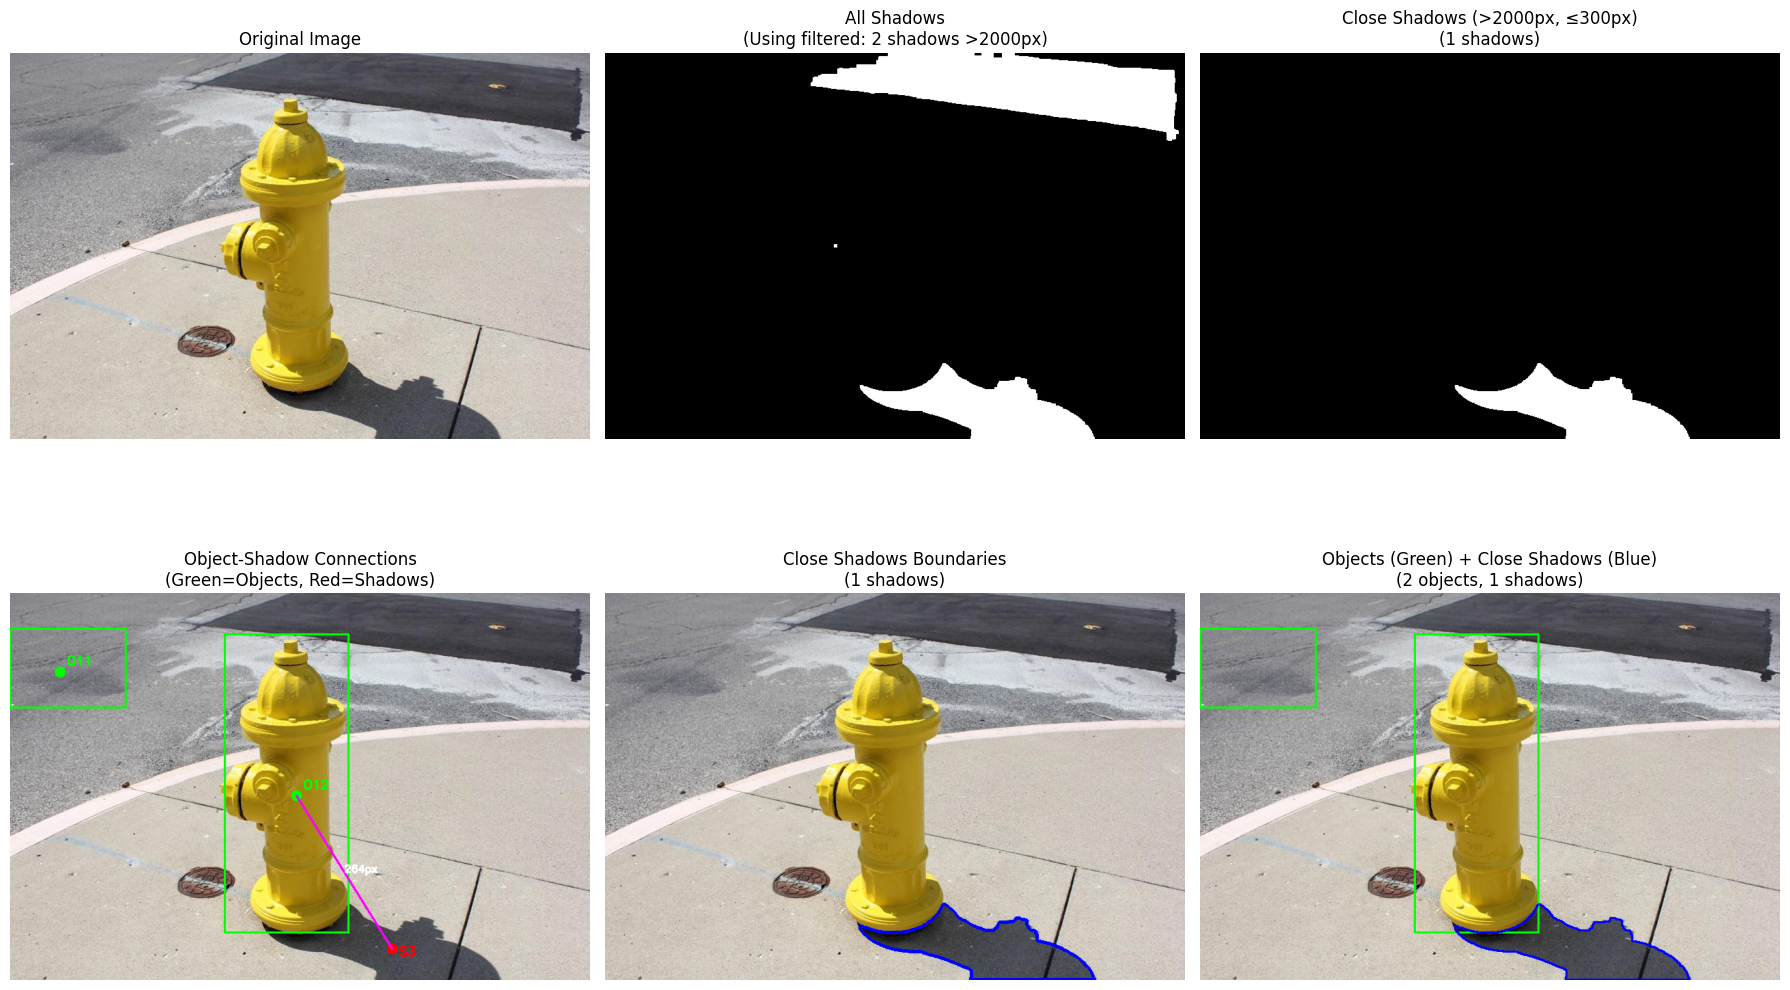


Object-Shadow Pairing Details:
  Shadow 3 (Area: 18046 px, Max Length: 351.87 px) -> Object 12 (Area: 39749 px, Max Length: 436.04 px)
    Distance: 263.99 pixels
    Shadow Centroid: (559.1, 520.5)
    Object Centroid: (419.2, 296.7)


In [14]:
# Use already filtered shadow information from previous cell (shadows_component_info with area > 2000 px)
# No need to recalculate - reuse the existing filtered data

print(f"Number of detected objects: {len(filtered_component_info)}")
print(f"Number of filtered shadows (area > 2000 px): {len(shadows_component_info)}")

# Use the already filtered shadow information
filtered_shadow_info = shadows_component_info
print(f"Using shadows from previous cell: {len(filtered_shadow_info)} shadows")

# Calculate distance between each object centroid and each shadow centroid
def calculate_centroid_distance(centroid1, centroid2):
    """Calculate Euclidean distance between two centroids"""
    return np.sqrt((centroid1[0] - centroid2[0])**2 + (centroid1[1] - centroid2[1])**2)

# Set distance threshold (adjust as needed)
distance_threshold = 300  # pixels

# Store shadows that are close to any object
close_shadows = []
shadow_object_pairs = []

print("\nDistance calculations (for shadows > 2000 px):")
for shadow_info in filtered_shadow_info:
    shadow_centroid = shadow_info['centroid']
    min_distance = float('inf')
    closest_object_idx = -1
    
    # Find the closest object to this shadow
    for obj_idx, obj_info in enumerate(filtered_component_info):
        obj_centroid = obj_info['centroid']
        distance = calculate_centroid_distance(shadow_centroid, obj_centroid)
        
        if distance < min_distance:
            min_distance = distance
            closest_object_idx = obj_idx
    
    print(f"Shadow {shadow_info['label']} (Area: {shadow_info['area']} px) -> Closest Object: {filtered_component_info[closest_object_idx]['label']}, Distance: {min_distance:.2f} px")
    
    # Keep shadow if it's close enough to any object
    if min_distance <= distance_threshold:
        close_shadows.append(shadow_info)
        shadow_object_pairs.append((shadow_info, filtered_component_info[closest_object_idx], min_distance))

print(f"\nShadows within {distance_threshold} pixels of objects: {len(close_shadows)}")

# Create a new mask with only close shadows
close_shadow_mask = np.zeros_like(combined_shadow_mask)
for shadow_info in close_shadows:
    # Create mask for this shadow component using the shadow_labeled_img from previous cell
    component_mask = (shadow_labeled_img == shadow_info['label']).astype(np.uint8) * 255
    close_shadow_mask = cv2.bitwise_or(close_shadow_mask, component_mask)

# Find contours of close shadows
close_shadow_contours, _ = cv2.findContours(close_shadow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Visualize the results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# All detected shadows
axes[0, 1].imshow(combined_shadow_mask, cmap='gray')
axes[0, 1].set_title(f'All Shadows\n(Using filtered: {len(filtered_shadow_info)} shadows >2000px)')
axes[0, 1].axis('off')

# Filtered shadows (close to objects and > 2000px)
axes[0, 2].imshow(close_shadow_mask, cmap='gray')
axes[0, 2].set_title(f'Close Shadows (>2000px, ≤{distance_threshold}px)\n({len(close_shadows)} shadows)')
axes[0, 2].axis('off')

# Objects and their close shadows with distance lines
img_with_connections = img.copy()

# Draw objects in green
for obj_info in filtered_component_info:
    left, top, width, height = obj_info['bbox']
    cv2.rectangle(img_with_connections, (left, top), (left + width, top + height), (0, 255, 0), 2)
    obj_cx, obj_cy = int(obj_info['centroid'][0]), int(obj_info['centroid'][1])
    cv2.circle(img_with_connections, (obj_cx, obj_cy), 8, (0, 255, 0), -1)
    cv2.putText(img_with_connections, f"O{obj_info['label']}", (obj_cx + 10, obj_cy - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Draw close shadows in red and connection lines
for shadow_info, obj_info, distance in shadow_object_pairs:
    shadow_cx, shadow_cy = int(shadow_info['centroid'][0]), int(shadow_info['centroid'][1])
    obj_cx, obj_cy = int(obj_info['centroid'][0]), int(obj_info['centroid'][1])
    
    # Draw shadow centroid
    cv2.circle(img_with_connections, (shadow_cx, shadow_cy), 8, (0, 0, 255), -1)
    cv2.putText(img_with_connections, f"S{shadow_info['label']}", (shadow_cx + 10, shadow_cy + 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    
    # Draw connection line
    cv2.line(img_with_connections, (obj_cx, obj_cy), (shadow_cx, shadow_cy), (255, 0, 255), 2)
    
    # Add distance text at midpoint
    mid_x, mid_y = (obj_cx + shadow_cx) // 2, (obj_cy + shadow_cy) // 2
    cv2.putText(img_with_connections, f"{distance:.0f}px", (mid_x, mid_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

axes[1, 0].imshow(cv2.cvtColor(img_with_connections, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title(f'Object-Shadow Connections\n(Green=Objects, Red=Shadows)')
axes[1, 0].axis('off')

# Close shadows with boundaries
img_with_close_shadows = img.copy()
cv2.drawContours(img_with_close_shadows, close_shadow_contours, -1, (255, 0, 0), 3)
axes[1, 1].imshow(cv2.cvtColor(img_with_close_shadows, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Close Shadows Boundaries\n({len(close_shadows)} shadows)')
axes[1, 1].axis('off')

# Combined: Objects + Close Shadows
img_combined = img.copy()
# Draw objects in green
for info in filtered_component_info:
    left, top, width, height = info['bbox']
    cv2.rectangle(img_combined, (left, top), (left + width, top + height), (0, 255, 0), 2)
# Draw close shadows in red
cv2.drawContours(img_combined, close_shadow_contours, -1, (255, 0, 0), 2)
axes[1, 2].imshow(cv2.cvtColor(img_combined, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title(f'Objects (Green) + Close Shadows (Blue)\n({len(filtered_component_info)} objects, {len(close_shadows)} shadows)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Print detailed pairing information
print("\nObject-Shadow Pairing Details:")
for shadow_info, obj_info, distance in shadow_object_pairs:
    print(f"  Shadow {shadow_info['label']} (Area: {shadow_info['area']} px, Max Length: {shadow_info['max_length_actual']:.2f} px) -> Object {obj_info['label']} (Area: {obj_info['area']} px, Max Length: {obj_info['max_length_actual']:.2f} px)")
    print(f"    Distance: {distance:.2f} pixels")
    print(f"    Shadow Centroid: ({shadow_info['centroid'][0]:.1f}, {shadow_info['centroid'][1]:.1f})")
    print(f"    Object Centroid: ({obj_info['centroid'][0]:.1f}, {obj_info['centroid'][1]:.1f})")

In [15]:
def calculate_sun_elevation(object_length, shadow_length):
    """
    Calculate sun elevation angle using the formula: tan(θ) = object_length / shadow_length
    
    Parameters:
    object_length: length of the object in pixels
    shadow_length: length of the shadow in pixels
    
    Returns:
    elevation_angle_deg: sun elevation angle in degrees
    elevation_angle_rad: sun elevation angle in radians
    """
    # Calculate elevation angle in radians
    elevation_angle_rad = np.arctan(object_length / shadow_length)
    
    # Convert to degrees
    elevation_angle_deg = np.degrees(elevation_angle_rad)
    
    return elevation_angle_deg, elevation_angle_rad

# Use only the last object-shadow pair
if shadow_object_pairs:
    # Get the last pair
    last_shadow_info, last_obj_info, last_distance = shadow_object_pairs[-1]
    
    object_length = last_obj_info['max_length_actual']
    shadow_length = last_shadow_info['max_length_actual']
    
    # Calculate sun elevation angle
    elevation_deg, elevation_rad = calculate_sun_elevation(object_length, shadow_length)
    
    print("Sun Elevation Angle Calculation (Last Object-Shadow Pair):")
    print("=" * 80)
    print(f"Object {last_obj_info['label']} <-> Shadow {last_shadow_info['label']}:")
    print(f"  Object Length: {object_length:.2f} pixels")
    print(f"  Shadow Length: {shadow_length:.2f} pixels")
    print(f"  Ratio (Object/Shadow): {object_length/shadow_length:.4f}")
    print(f"  Sun Elevation Angle: {elevation_deg:.2f}° ({elevation_rad:.4f} radians)")
else:
    print("No object-shadow pairs found for calculation.")

Sun Elevation Angle Calculation (Last Object-Shadow Pair):
Object 12 <-> Shadow 3:
  Object Length: 436.04 pixels
  Shadow Length: 351.87 pixels
  Ratio (Object/Shadow): 1.2392
  Sun Elevation Angle: 51.10° (0.8918 radians)


In [16]:
from pysolar.solar import get_altitude
from datetime import datetime, timedelta
import pytz

def estimate_time_from_elevation(target_elevation, latitude, longitude, date=None):
    """
    Estimate the time of day when the sun reaches a specific elevation angle
    
    Parameters:
    target_elevation: desired sun elevation angle in degrees
    latitude: latitude of the location
    longitude: longitude of the location
    date: date to search (default: today)
    
    Returns:
    times: list of times when sun reaches the target elevation (usually 2: morning and afternoon)
    """
    if date is None:
        date = datetime.now().date()
    
    # Create timezone-aware datetime
    tz = pytz.UTC
    
    # Search through the day in 1-minute intervals
    times = []
    start_time = datetime.combine(date, datetime.min.time()).replace(tzinfo=tz)
    
    prev_altitude = None
    prev_time = None
    
    for minute in range(24 * 60):  # 24 hours * 60 minutes
        current_time = start_time + timedelta(minutes=minute)
        altitude = get_altitude(latitude, longitude, current_time)
        
        # Check if we crossed the target elevation
        if prev_altitude is not None:
            if (prev_altitude < target_elevation <= altitude) or \
               (prev_altitude > target_elevation >= altitude):
                # Interpolate to get more precise time
                times.append(current_time)
        
        prev_altitude = altitude
        prev_time = current_time
    
    return times

# Use the calculated elevation angle to estimate time
if shadow_object_pairs and 'elevation_deg' in locals():
    # Example coordinates (you can change these to your actual location)
    # Using Dhaka, Bangladesh as an example
    latitude = 23.8103  # Dhaka latitude
    longitude = 90.4125  # Dhaka longitude
    
    print("\n" + "=" * 80)
    print("Time Estimation Using Pysolar:")
    print("=" * 80)
    print(f"Location: Latitude {latitude}°, Longitude {longitude}°")
    print(f"Target Sun Elevation: {elevation_deg:.2f}°")
    
    # Estimate times for today
    estimated_times = estimate_time_from_elevation(elevation_deg, latitude, longitude)
    
    if estimated_times:
        print(f"\nEstimated times when sun reaches {elevation_deg:.2f}° elevation:")
        for i, time in enumerate(estimated_times, 1):
            # Convert to local timezone for better readability
            local_tz = pytz.timezone('Asia/Dhaka')  # Change this to your timezone
            local_time = time.astimezone(local_tz)
            print(f"  Time {i}: {local_time.strftime('%Y-%m-%d %I:%M:%S %p %Z')}")
            
            # Verify the elevation at this time
            actual_elevation = get_altitude(latitude, longitude, time)
            print(f"    Actual sun elevation: {actual_elevation:.2f}°")
    else:
        print(f"\nNo times found today when sun reaches {elevation_deg:.2f}° elevation.")
        print("This elevation might not be reachable at this location on this date.")
else:
    print("No elevation angle calculated. Run the previous cell first.")


Time Estimation Using Pysolar:
Location: Latitude 23.8103°, Longitude 90.4125°
Target Sun Elevation: 51.10°

Estimated times when sun reaches 51.10° elevation:
  Time 1: 2025-10-31 11:08:00 AM +06
    Actual sun elevation: 51.12°
  Time 2: 2025-10-31 12:17:00 PM +06
    Actual sun elevation: 51.05°
